# NoyoSafe — Entrenamiento de un detector de accidentes (YOLOv8)

**Proyecto:** NoyoSafe — Sistema de Detección Automática de Accidentes de Tránsito
**Autores:** Joseph Flores, Mateo Ortega — Inteligencia Artificial 1, UDLA

## Contexto (Informe de Etapa 2: Diseño e Implementación)

El sistema actual (`src/detector.py`) detecta accidentes con dos piezas, documentadas en el informe:

1. **YOLOv8n preentrenado en COCO** (`yolov8n.pt`) para detectar vehículos (clases 2/3/5/7: car,
   motorcycle, bus, truck), con seguimiento persistente vía ByteTrack.
2. Una **regla geométrica/cinemática**: dos vehículos "chocan" si el IoU de sus cajas supera
   `COLLISION_IOU_THRESHOLD` (0.05) **y** alguno tuvo un cambio de velocidad > `SPEED_CHANGE_THRESHOLD`
   (5 px/frame) respecto al historial de `speed_history`.

Los resultados preliminares reportados en el informe (Sección 4.2, dataset CADP, CPU Intel i7-11800H) son:

| Experimento | Resultado |
|---|---|
| Exp. 1 — Vehículos | Precisión 0.87, Recall 0.82, F1 0.84 |
| Exp. 2 — Accidentes | TPR 0.73, FPR 0.14, F1 0.71 (criterio de éxito: TPR > 70%, FPR < 20%) |
| Exp. 3 — Latencia | CPU 34.7 ms/frame (28.8 FPS); GPU 9.1 ms/frame (109.9 FPS), speedup ~3.8x |
| Exp. 4 — Condiciones adversas | F1 cae de 0.71 (base) a 0.59 (night), 0.64 (rain_day), 0.56 (heavy_fog) |

La Sección 5 del informe ("Mejoras a Incluir") propone explícitamente, entre otras cosas:

- **§5.2** — *"Implementar el dataset de entrenamiento con aumentos de datos que simulen las condiciones
  adversas (lluvia, niebla, baja iluminación) para fine-tuning del modelo sobre escenas de vigilancia vial
  similares a CADP."*
- **§5.4** — *"Implementar curvas Precision-Recall y ROC... al variar `COLLISION_IOU_THRESHOLD` y
  `SPEED_CHANGE_THRESHOLD`"* y construir una evaluación más rigurosa y balanceada.

**Este notebook implementa exactamente esas dos mejoras**, entrenando un modelo que reconoce accidentes
directamente en la imagen (no solo geometría entre vehículos), usando dos fuentes de datos reales:

- Roboflow — [`accident-detection-model`](https://universe.roboflow.com/accident-detection-model/accident-detection-model):
  3250 imágenes anotadas en formato YOLOv8, clase única `Accident`, licencia CC BY 4.0. KhxPNEi8dMVZGTZND7pk
- **CADP** (Car Accident Detection and Prediction) — el mismo dataset citado en la Sección 3.4 del informe
  como fuente de datos del desarrollo inicial —
  [ankitshah009.github.io/accident_forecasting_traffic_camera](https://ankitshah009.github.io/accident_forecasting_traffic_camera):
  1416 videos CCTV reales de YouTube, 205 con anotaciones espacio-temporales completas. Uso no comercial,
  requiere permiso del autor.

## Qué hace este notebook

1. Descarga y limpia ambos datasets, y los combina en un único dataset YOLO.
2. **Aumenta el set de entrenamiento con los filtros adversos que ya existen en `src/filters.py`**
   (lluvia, niebla, baja luz, noche) — implementando la mejora de la §5.2 del informe.
3. Entrena (fine-tuning) un YOLOv8n sobre la clase `accident`.
4. Compara, con métricas calculadas sobre el mismo set de test, dos modelos:
   - **Modelo normal**: YOLOv8n de COCO + la heurística geométrica que ya usa `src/detector.py`
     (constantes importadas directamente del módulo, no reescritas).
   - **Modelo entrenado**: el YOLOv8n con fine-tuning de este notebook.
5. Grafica la diferencia con el mismo vocabulario del informe (**TPR, FPR**, Precisión, Recall, F1),
   agrega **curvas Precision-Recall y ROC** variando `COLLISION_IOU_THRESHOLD` / la confianza del modelo
   entrenado (mejora §5.4), y repite el **Experimento 4** (condiciones adversas) para ambos modelos.
6. Guarda una tabla de resultados lista para pegar en la siguiente versión del informe.

> Todas las conclusiones se calculan a partir de las métricas obtenidas al correr el notebook — no hay
> números fijos de antemano. Si lo corrés con otros datos, los gráficos y la tabla final se recalculan solos.


## Requisitos antes de correr

- **GPU recomendada** (Google Colab: `Entorno de ejecución > Cambiar tipo de entorno > GPU`). En CPU
  funciona igual pero el entrenamiento tarda mucho más (ver Exp. 3 del informe: CPU ~3.8x más lento que GPU).
- **API key de Roboflow** (gratis): crea una cuenta en [roboflow.com](https://roboflow.com) y copia tu
  API key desde `Settings > API Keys`. Se pedirá más abajo con un prompt oculto (no se guarda en el notebook).
- **Dataset CADP (opcional)**: requiere pedir acceso siguiendo las instrucciones de la página del proyecto
  (ver Sección 2). Si no lo configurás, el notebook **sigue funcionando solo con el dataset de Roboflow**.
- Ejecutar este notebook desde la carpeta `notebooks/` del repo (para que las rutas relativas `..` apunten
  a la raíz del proyecto y se puedan importar los módulos de `src/`).


## 0. Instalación de dependencias

In [4]:
%pip install -q ultralytics roboflow gdown opencv-python-headless pandas matplotlib pillow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Configuración global, semillas y estilo de gráficos

In [5]:
import os, sys, json, glob, shutil, random, time, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
from PIL import Image

random.seed(42)
np.random.seed(42)

# Paleta consistente para todos los gráficos del notebook.
COLOR_BASELINE = "#898781"   # modelo normal (heurística) -> tinta secundaria/gris
COLOR_TRAINED  = "#2a78d6"   # modelo entrenado -> azul
COLOR_ACCIDENT = "#e34948"   # clase "accidente" en gráficos de distribución
COLOR_NOACC    = "#2a78d6"   # clase "sin accidente" en gráficos de distribución
COLOR_GRID     = "#e1e0d9"
COLOR_TEXT     = "#0b0b0b"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "axes.edgecolor":    COLOR_GRID,
    "axes.grid":         True,
    "grid.color":        COLOR_GRID,
    "grid.linewidth":    0.8,
    "axes.axisbelow":    True,
    "text.color":        COLOR_TEXT,
    "axes.labelcolor":   COLOR_TEXT,
    "xtick.color":       "#52514e",
    "ytick.color":       "#52514e",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Este notebook está pensado para correr desde notebooks/, un nivel bajo la raíz del proyecto.
PROJECT_ROOT = Path("..").resolve()
DATASET_DIR  = PROJECT_ROOT / "data" / "accident_dataset"    # dataset combinado final (YOLO)
RAW_DIR      = PROJECT_ROOT / "data" / "raw_sources"         # descargas crudas de cada fuente
REPORTS_DIR  = PROJECT_ROOT / "outputs" / "reports"
RUNS_DIR     = PROJECT_ROOT / "runs_training"

for d in (DATASET_DIR, RAW_DIR, REPORTS_DIR, RUNS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Se importan las constantes y filtros directamente de src/, para que la heurística y los presets
# evaluados en este notebook sean EXACTAMENTE los que corre src/detector.py en producción.
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from detector import VEHICLE_CLASSES, COLLISION_IOU_THRESHOLD, SPEED_CHANGE_THRESHOLD, CONFIDENCE_THRESHOLD
from filters import PRESETS

# Criterios de éxito del Experimento 2, Informe de Etapa 2, Sección 4.
TPR_SUCCESS_THRESHOLD = 0.70
FPR_SUCCESS_THRESHOLD = 0.20

print("Raíz del proyecto:", PROJECT_ROOT)
print("Constantes importadas de src/detector.py:")
print(f"  VEHICLE_CLASSES={VEHICLE_CLASSES}  COLLISION_IOU_THRESHOLD={COLLISION_IOU_THRESHOLD}  "
      f"SPEED_CHANGE_THRESHOLD={SPEED_CHANGE_THRESHOLD}  CONFIDENCE_THRESHOLD={CONFIDENCE_THRESHOLD}")
print("Presets de condiciones adversas disponibles:", list(PRESETS.keys()))


Raíz del proyecto: C:\Users\dddma\OneDrive\Escritorio\Codigos_repors\IA_noyosafe
Constantes importadas de src/detector.py:
  VEHICLE_CLASSES=[2, 3, 5, 7]  COLLISION_IOU_THRESHOLD=0.05  SPEED_CHANGE_THRESHOLD=5  CONFIDENCE_THRESHOLD=0.4
Presets de condiciones adversas disponibles: ['night', 'rain_day', 'heavy_fog', 'low_light', 'rain', 'fog']


## 2. Dataset A — Roboflow `accident-detection-model`

- 3250 imágenes, clase única `Accident`, formato YOLOv8, licencia CC BY 4.0.
- Recolectadas de YouTube, Google Images y Kaggle; anotadas manualmente en Roboflow.
- Split original del autor: 8:1:1 (train/valid/test).

El código de abajo descarga la **versión más reciente** publicada del dataset. Si querés fijar una
versión específica, reemplazá `rf_project.versions()[-1].version` por el número de versión que quieras.


In [6]:
from getpass import getpass
from roboflow import Roboflow

ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY") or getpass("Roboflow API key: ")

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
rf_project = rf.workspace("accident-detection-model").project("accident-detection-model")

rf_version_number = rf_project.versions()[-1].version
rf_version = rf_project.version(rf_version_number)

roboflow_dataset = rf_version.download("yolov8", location=str(RAW_DIR / "roboflow_accident"))
print("Dataset Roboflow descargado en:", roboflow_dataset.location)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to C:\Users\dddma\OneDrive\Escritorio\Codigos_repors\IA_noyosafe\data\raw_sources\roboflow_accident in yolov8:: 100%|██████████| 2528/2528 [00:01<00:00, 1679.77it/s]

Dataset Roboflow descargado en: C:\Users\dddma\OneDrive\Escritorio\Codigos_repors\IA_noyosafe\data\raw_sources\roboflow_accident


## 3. Dataset B — CADP / Traffic Camera Accident Forecasting (opcional)

Este es el **dataset citado en la Sección 3.4 del Informe de Etapa 2** como fuente de datos del desarrollo
inicial de NoyoSafe: 1416 segmentos de video de CCTV reales de YouTube, 205 con **anotaciones
espacio-temporales completas** (bounding box del accidente en cada frame). Es el mismo tipo de escena
(cámara de vigilancia fija) que procesa `src/detector.py`, y el mismo dataset detrás de los formatos
`gt_accidentes.json` / `gt_vehiculos.json` que usa `src/evaluator.py`.

**No se puede descargar automáticamente**: el uso es no comercial y requiere permiso del autor. Pasos:

1. Visitá <https://ankitshah009.github.io/accident_forecasting_traffic_camera> y seguí el enlace al
   repositorio/README del dataset (frames extraídos + anotaciones JSON, hospedados en Google Drive).
2. Solicitá acceso si es necesario y conseguí los IDs de archivo/carpeta de Google Drive.
3. Pegá esos IDs en `CADP_FRAMES_GDRIVE_ID` / `CADP_ANNOTATIONS_GDRIVE_ID` en la siguiente celda.

Si dejás esos IDs vacíos, el notebook **imprime un aviso y continúa solo con el dataset de Roboflow** —
todo el resto del pipeline (limpieza, aumento de datos, entrenamiento, comparación) sigue corriendo igual.

> **Nota sobre el parser:** el formato exacto del JSON de anotaciones de CADP puede variar según cómo lo
> descargues. La celda de conversión intenta claves comunes (`frames`/`annotations`, `bboxes`/`boxes`,
> `frame_id`/`frame`) e imprime las claves del primer archivo para que ajustes el parser si no calzan.


In [7]:
import gdown

# --- Completá esto después de conseguir acceso al dataset CADP (ver celda de arriba) ---
CADP_FRAMES_GDRIVE_ID      = ""   # ID de la carpeta/zip de frames extraídos
CADP_ANNOTATIONS_GDRIVE_ID = ""   # ID del zip/JSON de anotaciones espacio-temporales

CADP_DIR = RAW_DIR / "cadp"
cadp_available = bool(CADP_FRAMES_GDRIVE_ID and CADP_ANNOTATIONS_GDRIVE_ID)

if cadp_available:
    CADP_DIR.mkdir(parents=True, exist_ok=True)
    gdown.download(id=CADP_FRAMES_GDRIVE_ID, output=str(CADP_DIR / "frames.zip"), quiet=False)
    gdown.download(id=CADP_ANNOTATIONS_GDRIVE_ID, output=str(CADP_DIR / "annotations.zip"), quiet=False)
    shutil.unpack_archive(str(CADP_DIR / "frames.zip"), str(CADP_DIR / "frames"))
    shutil.unpack_archive(str(CADP_DIR / "annotations.zip"), str(CADP_DIR / "annotations"))
    print("CADP descargado y descomprimido.")
else:
    print("[INFO] CADP_FRAMES_GDRIVE_ID / CADP_ANNOTATIONS_GDRIVE_ID no configurados.")
    print("       Se continúa solo con el dataset de Roboflow. Ver Sección 3 para incluir CADP.")


[INFO] CADP_FRAMES_GDRIVE_ID / CADP_ANNOTATIONS_GDRIVE_ID no configurados.
       Se continúa solo con el dataset de Roboflow. Ver Sección 3 para incluir CADP.


### 3.1 Conversión de anotaciones CADP a formato YOLO

In [8]:
CADP_YOLO_DIR = RAW_DIR / "cadp_yolo"
(CADP_YOLO_DIR / "images").mkdir(parents=True, exist_ok=True)
(CADP_YOLO_DIR / "labels").mkdir(parents=True, exist_ok=True)

def _bbox_to_yolo(bbox, img_w, img_h):
    """bbox en píxeles [x1, y1, x2, y2] -> 'xc yc w h' normalizado (formato YOLO)."""
    x1, y1, x2, y2 = bbox
    xc = ((x1 + x2) / 2) / img_w
    yc = ((y1 + y2) / 2) / img_h
    w  = (x2 - x1) / img_w
    h  = (y2 - y1) / img_h
    return xc, yc, w, h

n_converted = 0

if cadp_available:
    ann_files = list((CADP_DIR / "annotations").rglob("*.json"))
    print(f"Anotaciones CADP encontradas: {len(ann_files)}")

    if ann_files:
        sample = json.load(open(ann_files[0], encoding="utf-8"))
        print("Claves del primer JSON (ajustá el parser si difieren):",
              list(sample.keys()) if isinstance(sample, dict) else type(sample))

    for ann_path in ann_files:
        try:
            data = json.load(open(ann_path, encoding="utf-8"))
        except Exception:
            continue

        # NOTA: adaptá estas claves al esquema real de tu descarga de CADP si no calzan.
        frames_info = data.get("frames") or data.get("annotations") or []
        video_id = data.get("video_id", ann_path.stem)

        for fr in frames_info:
            frame_id = fr.get("frame_id") or fr.get("frame")
            bboxes   = fr.get("bboxes") or fr.get("boxes") or []
            img_path = CADP_DIR / "frames" / str(video_id) / f"{frame_id}.jpg"
            if frame_id is None or not img_path.exists() or not bboxes:
                continue

            with Image.open(img_path) as im:
                w, h = im.size

            dest_img = CADP_YOLO_DIR / "images" / f"{video_id}_{frame_id}.jpg"
            dest_lbl = CADP_YOLO_DIR / "labels" / f"{video_id}_{frame_id}.txt"
            shutil.copy(img_path, dest_img)
            with open(dest_lbl, "w", encoding="utf-8") as f:
                for bbox in bboxes:
                    xc, yc, w_n, h_n = _bbox_to_yolo(bbox, w, h)
                    f.write(f"0 {xc:.6f} {yc:.6f} {w_n:.6f} {h_n:.6f}\n")
            n_converted += 1

print(f"Frames CADP convertidos a formato YOLO: {n_converted}")


Frames CADP convertidos a formato YOLO: 0


## 4. Limpieza y validación de datos

Antes de entrenar, se valida cada imagen/etiqueta de ambas fuentes:

- **Imágenes corruptas** (no abren con PIL) → se descartan.
- **Etiquetas inválidas** (formato distinto a `clase xc yc w h`, o valores fuera de `[0, 1]`) → se reportan.
- **Duplicados** (mismo hash MD5 de contenido) → se cuentan.
- Conteo de imágenes **con accidente** vs **background** (sin caja, negativo). El informe (§5.4) pide un
  set de evaluación **balanceado** — este conteo es la base para verificarlo antes de entrenar.


In [9]:
def find_image_label_pairs(images_dir, labels_dir):
    pairs = []
    for img_path in sorted(Path(images_dir).glob("*.*")):
        if img_path.suffix.lower() not in (".jpg", ".jpeg", ".png"):
            continue
        lbl_path = Path(labels_dir) / (img_path.stem + ".txt")
        pairs.append((img_path, lbl_path))
    return pairs

def validate_split(images_dir, labels_dir, name=""):
    pairs = find_image_label_pairs(images_dir, labels_dir)
    stats = {"total": len(pairs), "corrupt": 0, "invalid_label": 0,
              "with_accident": 0, "background": 0, "duplicates": 0}
    seen_hashes = set()

    for img_path, lbl_path in pairs:
        try:
            with Image.open(img_path) as im:
                im.verify()
        except Exception:
            stats["corrupt"] += 1
            continue

        h = hashlib.md5(img_path.read_bytes()).hexdigest()
        if h in seen_hashes:
            stats["duplicates"] += 1
        seen_hashes.add(h)

        if lbl_path.exists() and lbl_path.read_text(encoding="utf-8").strip():
            valid = True
            for line in lbl_path.read_text(encoding="utf-8").strip().splitlines():
                parts = line.split()
                if len(parts) != 5:
                    valid = False
                    break
                _, xc, yc, w, hh = parts
                if not all(0.0 <= float(v) <= 1.0 for v in (xc, yc, w, hh)):
                    valid = False
                    break
            stats["with_accident" if valid else "invalid_label"] += 1
        else:
            stats["background"] += 1

    print(f"[{name}] {stats}")
    return stats

roboflow_splits = {}
for split, folder in (("train", "train"), ("val", "valid"), ("test", "test")):
    img_dir = Path(roboflow_dataset.location) / folder / "images"
    lbl_dir = Path(roboflow_dataset.location) / folder / "labels"
    if img_dir.exists():
        roboflow_splits[split] = validate_split(img_dir, lbl_dir, f"roboflow/{folder}")

if n_converted > 0:
    cadp_stats = validate_split(CADP_YOLO_DIR / "images", CADP_YOLO_DIR / "labels", "cadp")


[roboflow/train] {'total': 947, 'corrupt': 0, 'invalid_label': 0, 'with_accident': 501, 'background': 446, 'duplicates': 0}
[roboflow/valid] {'total': 154, 'corrupt': 0, 'invalid_label': 0, 'with_accident': 136, 'background': 18, 'duplicates': 0}
[roboflow/test] {'total': 157, 'corrupt': 0, 'invalid_label': 0, 'with_accident': 66, 'background': 91, 'duplicates': 0}


## 5. Unificación en un único dataset YOLO

Se copian ambas fuentes a `data/accident_dataset/{train,val,test}/{images,labels}` con un prefijo
(`rf_` o `cadp_`) para evitar colisiones de nombres, y se genera un `data.yaml` combinado con una sola
clase (`accident`). CADP no trae splits oficiales, así que se divide 80/10/10 de forma aleatoria y
reproducible (semilla fija).


In [10]:
def copy_pairs(images_dir, labels_dir, split, tag):
    dst_img_dir = DATASET_DIR / split / "images"
    dst_lbl_dir = DATASET_DIR / split / "labels"
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)
    count = 0
    for img_path in Path(images_dir).glob("*.*"):
        if img_path.suffix.lower() not in (".jpg", ".jpeg", ".png"):
            continue
        lbl_path = Path(labels_dir) / (img_path.stem + ".txt")
        new_name = f"{tag}_{img_path.name}"
        shutil.copy(img_path, dst_img_dir / new_name)
        if lbl_path.exists():
            shutil.copy(lbl_path, dst_lbl_dir / (Path(new_name).stem + ".txt"))
        else:
            (dst_lbl_dir / (Path(new_name).stem + ".txt")).write_text("", encoding="utf-8")
        count += 1
    return count

rf_root = Path(roboflow_dataset.location)
n_rf_train = copy_pairs(rf_root / "train" / "images", rf_root / "train" / "labels", "train", "rf")
n_rf_val   = copy_pairs(rf_root / "valid" / "images", rf_root / "valid" / "labels", "val",   "rf")
n_rf_test  = copy_pairs(rf_root / "test"  / "images", rf_root / "test"  / "labels", "test",  "rf")
print(f"Roboflow -> train:{n_rf_train} val:{n_rf_val} test:{n_rf_test}")

if n_converted > 0:
    cadp_images = sorted((CADP_YOLO_DIR / "images").glob("*.jpg"))
    random.shuffle(cadp_images)
    n = len(cadp_images)
    cuts = {
        "train": cadp_images[: int(n * 0.8)],
        "val":   cadp_images[int(n * 0.8): int(n * 0.9)],
        "test":  cadp_images[int(n * 0.9):],
    }
    for split, imgs in cuts.items():
        dst_img_dir = DATASET_DIR / split / "images"
        dst_lbl_dir = DATASET_DIR / split / "labels"
        dst_img_dir.mkdir(parents=True, exist_ok=True)
        dst_lbl_dir.mkdir(parents=True, exist_ok=True)
        for img_path in imgs:
            lbl_path = CADP_YOLO_DIR / "labels" / (img_path.stem + ".txt")
            new_name = f"cadp_{img_path.name}"
            shutil.copy(img_path, dst_img_dir / new_name)
            shutil.copy(lbl_path, dst_lbl_dir / (Path(new_name).stem + ".txt"))
    print(f"CADP -> train:{len(cuts['train'])} val:{len(cuts['val'])} test:{len(cuts['test'])}")

data_yaml = f"""\
path: {DATASET_DIR.as_posix()}
train: train/images
val: val/images
test: test/images
names:
  0: accident
"""
(DATASET_DIR / "data.yaml").write_text(data_yaml, encoding="utf-8")
print(data_yaml)


Roboflow -> train:947 val:154 test:157
path: C:/Users/dddma/OneDrive/Escritorio/Codigos_repors/IA_noyosafe/data/accident_dataset
train: train/images
val: val/images
test: test/images
names:
  0: accident



## 6. Aumento de datos con condiciones adversas (mejora §5.2 del informe)

El informe (Sección 5.2) propone explícitamente entrenar con augmentations que simulen lluvia, niebla y
baja iluminación. En vez de reimplementar estos efectos, se reutilizan **los mismos presets de
`src/filters.py`** (`PRESETS`) que ya usa `detector.py --filter <preset>` — así el modelo entrenado queda
expuesto exactamente a las mismas degradaciones que el Experimento 4 del informe evalúa.

Se toma una fracción de las imágenes de **train** (no de val/test, para no filtrar información), se les
aplica un preset adverso aleatorio, y se agregan como ejemplos adicionales con la misma etiqueta que la
imagen original.


In [11]:
AUGMENT_FRACTION = 0.3   # proporción de imágenes de train que reciben un preset adverso adicional

train_img_dir = DATASET_DIR / "train" / "images"
train_lbl_dir = DATASET_DIR / "train" / "labels"

train_images_before = sorted(train_img_dir.glob("*.*"))
n_augment = int(len(train_images_before) * AUGMENT_FRACTION)
to_augment = random.sample(train_images_before, k=n_augment) if n_augment else []

n_aug_written = 0
for img_path in to_augment:
    preset_name, preset_fn = random.choice(list(PRESETS.items()))
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    degraded = preset_fn(img)

    new_name = f"aug_{preset_name}_{img_path.name}"
    cv2.imwrite(str(train_img_dir / new_name), degraded)

    lbl_path = train_lbl_dir / (img_path.stem + ".txt")
    dst_lbl  = train_lbl_dir / (Path(new_name).stem + ".txt")
    if lbl_path.exists():
        shutil.copy(lbl_path, dst_lbl)
    else:
        dst_lbl.write_text("", encoding="utf-8")
    n_aug_written += 1

print(f"Imágenes de train originales: {len(train_images_before)}")
print(f"Imágenes aumentadas con condiciones adversas (presets: {list(PRESETS.keys())}): {n_aug_written}")
print(f"Total de train tras el aumento: {len(train_images_before) + n_aug_written}")


Imágenes de train originales: 947
Imágenes aumentadas con condiciones adversas (presets: ['night', 'rain_day', 'heavy_fog', 'low_light', 'rain', 'fog']): 284
Total de train tras el aumento: 1231


## 7. Análisis exploratorio del dataset combinado (incluye el aumento de la Sección 6)


       accidente  sin_accidente
split                          
train        645            586
val          136             18
test          66             91


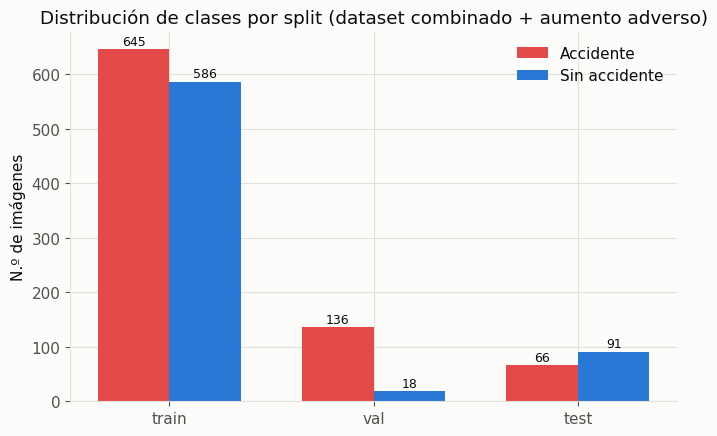

In [12]:
def count_split(split):
    lbl_dir = DATASET_DIR / split / "labels"
    files = list(lbl_dir.glob("*.txt"))
    with_acc = sum(1 for f in files if f.read_text(encoding="utf-8").strip())
    return len(files), with_acc, len(files) - with_acc

rows = []
for split in ("train", "val", "test"):
    total, acc, bg = count_split(split)
    rows.append({"split": split, "accidente": acc, "sin_accidente": bg})
df_counts = pd.DataFrame(rows).set_index("split")
print(df_counts)

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(df_counts))
width = 0.35
b1 = ax.bar(x - width/2, df_counts["accidente"], width, color=COLOR_ACCIDENT, label="Accidente")
b2 = ax.bar(x + width/2, df_counts["sin_accidente"], width, color=COLOR_NOACC, label="Sin accidente")
for bars in (b1, b2):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{int(h)}", (b.get_x() + b.get_width()/2, h),
                    textcoords="offset points", xytext=(0, 3), ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(df_counts.index)
ax.set_ylabel("N.º de imágenes")
ax.set_title("Distribución de clases por split (dataset combinado + aumento adverso)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "distribucion_clases.png", dpi=150)
plt.show()


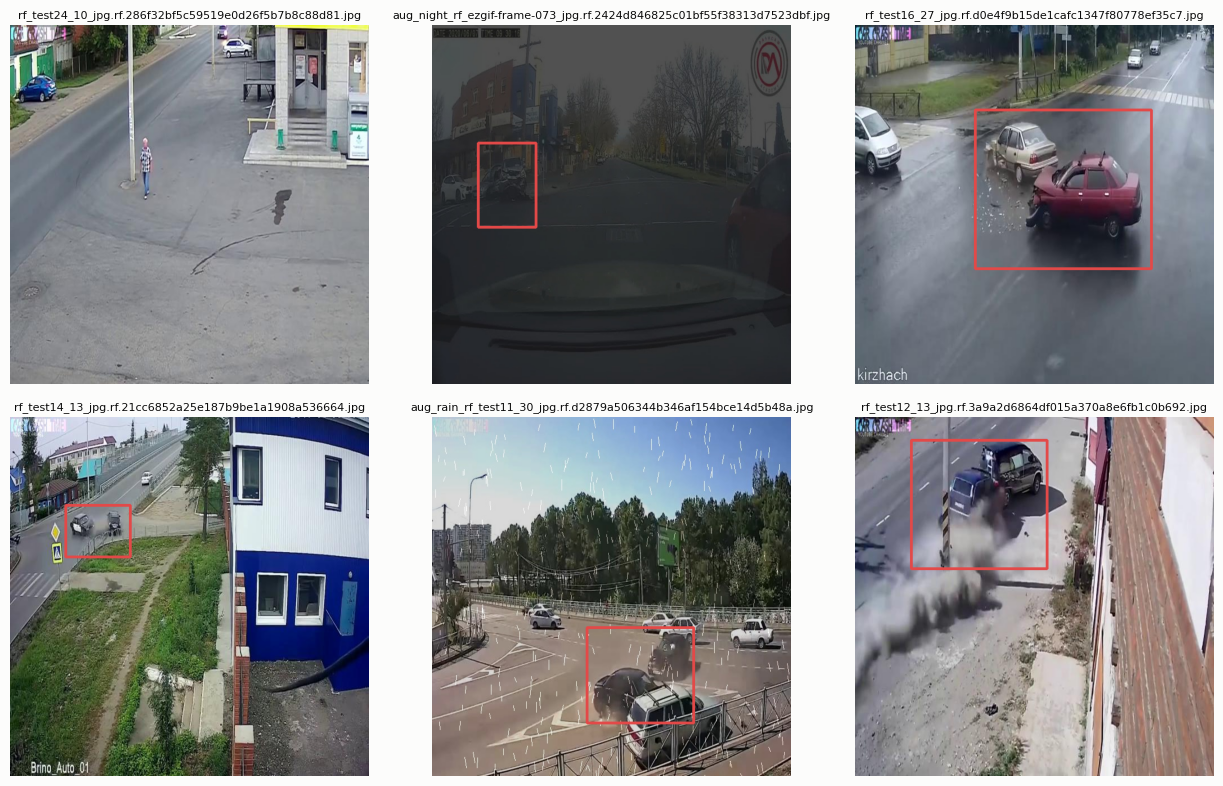

In [13]:
# Muestra visual de imágenes de entrenamiento con sus cajas (accidente en rojo).
# Incluye tanto imágenes originales como aumentadas (prefijo "aug_").
sample_imgs = random.sample(sorted(train_img_dir.glob("*.*")), k=6)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, img_path in zip(axes.flat, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = train_lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text(encoding="utf-8").strip().splitlines():
            _, xc, yc, bw, bh = map(float, line.split())
            x1, y1 = int((xc - bw/2) * w), int((yc - bh/2) * h)
            x2, y2 = int((xc + bw/2) * w), int((yc + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (227, 73, 72), 3)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "muestra_dataset.png", dpi=150)
plt.show()


## 8. Los dos modelos que se van a comparar

| | Modelo normal (baseline) | Modelo entrenado |
|---|---|---|
| Pesos | `yolov8n.pt` (COCO, sin modificar) | `yolov8n.pt` + fine-tuning en `accident` (+ augmentations adversas) |
| Cómo decide "accidente" | Heurística geométrica de `src/detector.py`: IoU entre cajas de vehículos ≥ `COLLISION_IOU_THRESHOLD` (+ cambio de velocidad si hay video) | Detección directa de la clase `accident` aprendida |
| Requiere tracking/video | Sí, para la señal de velocidad | No, funciona en una sola imagen |
| Constantes | Importadas de `src/detector.py` (no reescritas) | `CONFIDENCE_THRESHOLD` de `src/detector.py` |
| Dónde se evalúa | Mismo set de test combinado | Mismo set de test combinado |

**Limitación importante y honesta:** el set de test son imágenes sueltas (no video), así que la heurística
del "modelo normal" pierde la señal de cambio de velocidad (necesita ≥3 frames de historial) y solo puede
usar la condición de solapamiento geométrico. Esto es exactamente lo que corre `detect_collision()` en
`src/detector.py` cuando no hay suficiente historial de tracking — no es una versión debilitada a propósito,
es el mismo código, en el mismo escenario límite.

El criterio de éxito que usa el informe para el Experimento 2 (**TPR > 70%, FPR < 20%**) se marca como
referencia en los gráficos de la Sección 11.


## 9. Entrenamiento (fine-tuning de YOLOv8n)

In [14]:
import torch
from ultralytics import YOLO

EPOCHS   = 60
IMG_SIZE = 640
BATCH    = 16
PATIENCE = 15

device = 0 if torch.cuda.is_available() else "cpu"
print("Dispositivo de entrenamiento:", "GPU" if device == 0 else "CPU")

trained_model = YOLO("yolov8n.pt")   # mismo punto de partida que usa src/detector.py (MODEL_PATH)

train_results = trained_model.train(
    data=str(DATASET_DIR / "data.yaml"),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    patience=PATIENCE,
    project=str(RUNS_DIR),
    name="accident_yolov8n",
    seed=42,
    device=device,
)

BEST_WEIGHTS = Path(train_results.save_dir) / "weights" / "best.pt"
print("Mejor checkpoint guardado en:", BEST_WEIGHTS)


Dispositivo de entrenamiento: GPU
New https://pypi.org/project/ultralytics/8.4.90 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.52  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\dddma\OneDrive\Escritorio\Codigos_repors\IA_noyosafe\data\accident_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mas

### 9.1 Curvas de entrenamiento

> **Nota (§5.2 del informe):** si además querés comparar `yolov8s`/`yolov8m` para condiciones de baja
> visibilidad (como sugiere el informe), repetí esta celda cambiando `YOLO("yolov8n.pt")` por
> `YOLO("yolov8s.pt")` y guardando los resultados en un `name=` distinto — el resto del notebook no cambia.


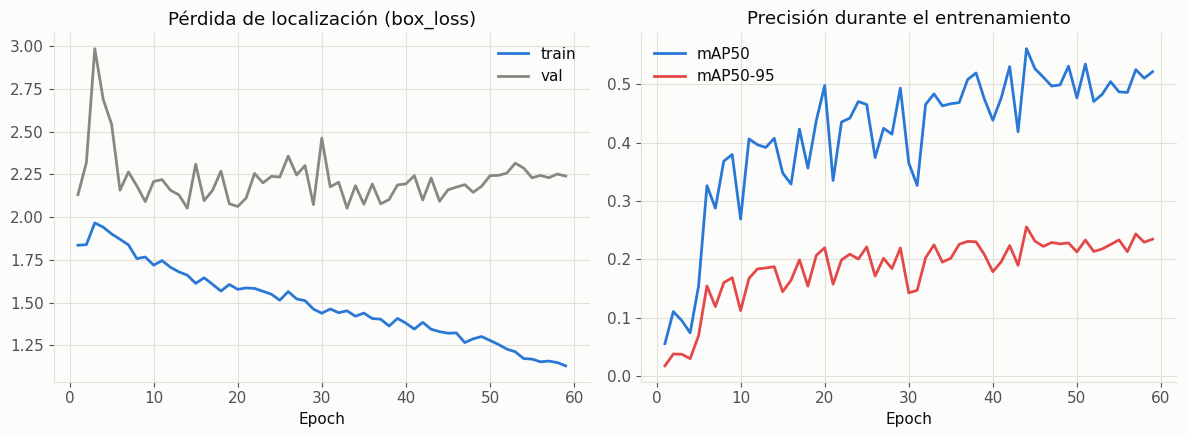

In [15]:
results_csv = Path(train_results.save_dir) / "results.csv"
df_hist = pd.read_csv(results_csv)
df_hist.columns = [c.strip() for c in df_hist.columns]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_hist["epoch"], df_hist["train/box_loss"], color=COLOR_TRAINED, linewidth=2, label="train")
axes[0].plot(df_hist["epoch"], df_hist["val/box_loss"], color=COLOR_BASELINE, linewidth=2, label="val")
axes[0].set_title("Pérdida de localización (box_loss)")
axes[0].set_xlabel("Epoch")
axes[0].legend(frameon=False)

axes[1].plot(df_hist["epoch"], df_hist["metrics/mAP50(B)"], color=COLOR_TRAINED, linewidth=2, label="mAP50")
axes[1].plot(df_hist["epoch"], df_hist["metrics/mAP50-95(B)"], color=COLOR_ACCIDENT, linewidth=2, label="mAP50-95")
axes[1].set_title("Precisión durante el entrenamiento")
axes[1].set_xlabel("Epoch")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "curvas_entrenamiento.png", dpi=150)
plt.show()


## 10. Evaluación en el set de test

### 10.1 Modelo entrenado — métricas nativas de YOLO (mAP, precisión, recall)


In [16]:
best_model = YOLO(str(BEST_WEIGHTS))
val_metrics = best_model.val(data=str(DATASET_DIR / "data.yaml"), split="test", imgsz=IMG_SIZE)

trained_yolo_metrics = {
    "precision": float(val_metrics.box.mp),
    "recall":    float(val_metrics.box.mr),
    "map50":     float(val_metrics.box.map50),
    "map50_95":  float(val_metrics.box.map),
}
print(trained_yolo_metrics)


Ultralytics 8.4.52  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 3.31.4 MB/s, size: 54.9 KB)
val: Scanning C:\Users\dddma\OneDrive\Escritorio\Codigos_repors\IA_noyosafe\data\accident_dataset\test\labels... 157 images, 91 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 157/157 594.3it/s 0.3s0.1s
val: New cache created: C:\Users\dddma\OneDrive\Escritorio\Codigos_repors\IA_noyosafe\data\accident_dataset\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 9.8it/s 1.0s.2s
                   all        157         81       0.78      0.926      0.886       0.44
Speed: 1.5ms preprocess, 2.5ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\Users\dddma\OneDrive\Escritorio\Codigos_repors\IA_noyosafe\notebooks\runs\detect\val
{'precisio

### 10.2 Modelo normal (baseline) — misma regla que `src/detector.py`

Se corre `yolov8n.pt` (COCO) sobre cada imagen de test, se detectan vehículos y se calcula el **IoU máximo**
entre pares (la misma cantidad que compara `detect_collision()` contra `COLLISION_IOU_THRESHOLD`). Para el
modelo entrenado se guarda la **confianza máxima** de la clase `accident` detectada. Guardar estos valores
crudos (en vez de solo un booleano) permite reevaluar con distintos umbrales sin volver a correr el modelo
— necesario para las curvas PR/ROC de la Sección 11.


In [17]:
baseline_model = YOLO("yolov8n.pt")   # pesos originales, sin fine-tuning

def iou(b1, b2):
    x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    if inter == 0:
        return 0.0
    a1 = (b1[2] - b1[0]) * (b1[3] - b1[1])
    a2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
    return inter / (a1 + a2 - inter)

def baseline_max_iou(image_path):
    """IoU máximo entre pares de vehículos -> el mismo valor que detect_collision() compara
    contra COLLISION_IOU_THRESHOLD en src/detector.py."""
    res = baseline_model.predict(str(image_path), classes=VEHICLE_CLASSES,
                                  conf=CONFIDENCE_THRESHOLD, verbose=False)
    boxes = res[0].boxes.xyxy.cpu().numpy().tolist() if res[0].boxes is not None else []
    best = 0.0
    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            best = max(best, iou(boxes[i], boxes[j]))
    return best

def trained_max_conf(image_path):
    """Confianza máxima de la clase 'accident' detectada por el modelo entrenado."""
    res = best_model.predict(str(image_path), conf=0.05, verbose=False)
    if res[0].boxes is None or len(res[0].boxes) == 0:
        return 0.0
    return float(res[0].boxes.conf.max())

test_images = sorted((DATASET_DIR / "test" / "images").glob("*.*"))
print(f"Imágenes de test: {len(test_images)}")

records = []
for img_path in test_images:
    lbl_path = DATASET_DIR / "test" / "labels" / (img_path.stem + ".txt")
    gt = 1 if (lbl_path.exists() and lbl_path.read_text(encoding="utf-8").strip()) else 0

    t0 = time.time(); max_iou_b = baseline_max_iou(img_path); t1 = time.time()
    max_conf_t = trained_max_conf(img_path); t2 = time.time()

    records.append({
        "image": img_path.name, "gt": gt,
        "max_iou_baseline": max_iou_b, "max_conf_trained": max_conf_t,
        "ms_baseline": (t1 - t0) * 1000, "ms_trained": (t2 - t1) * 1000,
    })

df_eval = pd.DataFrame(records)
df_eval["pred_baseline"] = (df_eval["max_iou_baseline"] >= COLLISION_IOU_THRESHOLD).astype(int)
df_eval["pred_trained"]  = (df_eval["max_conf_trained"]  >= CONFIDENCE_THRESHOLD).astype(int)
df_eval.to_csv(REPORTS_DIR / "predicciones_test.csv", index=False)
df_eval.head()


Imágenes de test: 157


,image,gt,max_iou_baseline,max_conf_trained,ms_baseline,ms_trained,pred_baseline,pred_trained
0,rf_5_17_jpg.rf.0611b10e50517e4323c47fc36301167...,0,0.0,0.000000,52.584171,17.014503,0,0
1,rf_5_22_jpg.rf.368e2a41bf84be83076f603939cbd05...,0,0.0,0.000000,8.987665,9.006262,0,0
2,rf_5_28_jpg.rf.3eabd78da3af251b71e0089ac63f9c8...,0,0.0,0.000000,9.995222,9.520292,0,0
3,rf_ezgif-frame-007_jpg.rf.ceac019216ee1df6dffd...,0,0.0,0.064023,9.004354,10.992050,0,0
4,rf_ezgif-frame-016_jpg.rf.ca0bcea30501ae4af64f...,0,0.0,0.063065,9.002209,8.996725,0,0


### 10.3 Métricas comparativas (TPR/FPR/Precision/Recall/F1, mismas fórmulas que `src/evaluator.py`)


In [18]:
def binary_metrics(gt, pred):
    gt, pred = np.array(gt), np.array(pred)
    tp = int(((gt == 1) & (pred == 1)).sum())
    fp = int(((gt == 0) & (pred == 1)).sum())
    fn = int(((gt == 1) & (pred == 0)).sum())
    tn = int(((gt == 0) & (pred == 0)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0        # == TPR
    fpr       = fp / (fp + tn) if (fp + tn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy  = (tp + tn) / len(gt) if len(gt) else 0.0
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": precision, "recall": recall, "tpr": recall, "fpr": fpr,
            "f1": f1, "accuracy": accuracy}

baseline_stats = binary_metrics(df_eval["gt"], df_eval["pred_baseline"])
trained_stats  = binary_metrics(df_eval["gt"], df_eval["pred_trained"])

baseline_stats["map50"] = None
baseline_stats["map50_95"] = None
trained_stats["map50"] = trained_yolo_metrics["map50"]
trained_stats["map50_95"] = trained_yolo_metrics["map50_95"]

baseline_stats["ms_avg"] = float(df_eval["ms_baseline"].mean())
trained_stats["ms_avg"]  = float(df_eval["ms_trained"].mean())

comparison = pd.DataFrame([
    {"modelo": "Normal (YOLOv8n COCO + heurística IoU)", **baseline_stats},
    {"modelo": "Entrenado (YOLOv8n fine-tuned 'accident')", **trained_stats},
])
comparison.to_csv(REPORTS_DIR / "comparacion_modelos.csv", index=False)
comparison


,modelo,tp,fp,fn,tn,precision,recall,tpr,fpr,f1,accuracy,map50,map50_95,ms_avg
0,Normal (YOLOv8n COCO + heurística IoU),16,17,50,74,0.484848,0.242424,0.242424,0.186813,0.323232,0.573248,NaN,NaN,10.581975
1,Entrenado (YOLOv8n fine-tuned 'accident'),65,32,1,59,0.670103,0.984848,0.984848,0.351648,0.797546,0.789809,0.886307,0.440321,10.131459


## 11. Curvas Precision-Recall y ROC (mejora §5.4 del informe)

El informe pide explícitamente *"implementar curvas Precision-Recall y ROC... al variar
`COLLISION_IOU_THRESHOLD`"*. Como ya se guardó el IoU máximo y la confianza máxima por imagen
(Sección 10.2), el barrido de umbrales es instantáneo — no hace falta volver a correr los modelos.


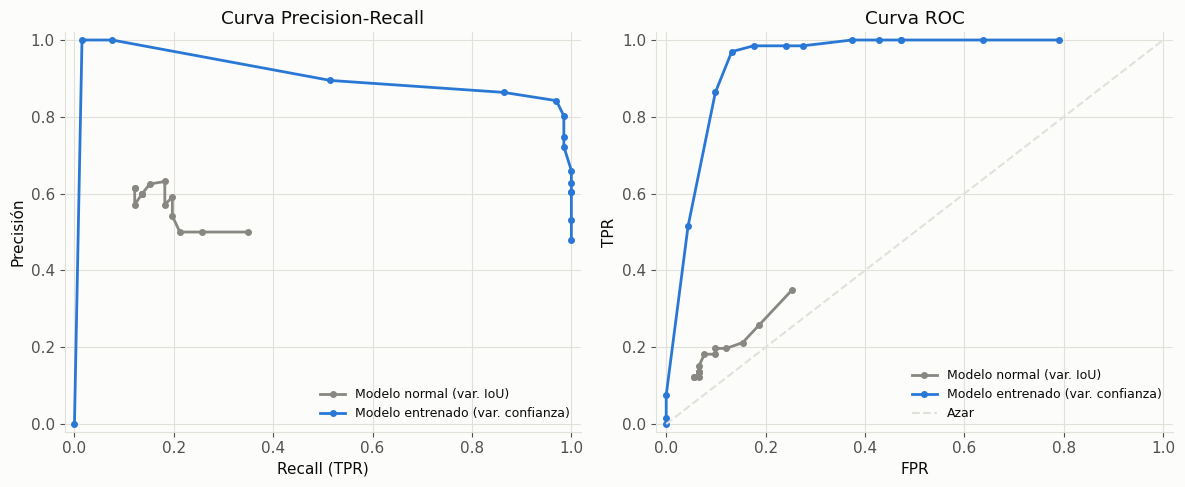

In [19]:
def sweep_metrics(scores, gt, thresholds):
    rows = []
    for thr in thresholds:
        pred = (scores >= thr).astype(int)
        rows.append({"threshold": thr, **binary_metrics(gt, pred)})
    return pd.DataFrame(rows)

iou_thresholds  = np.linspace(0.01, 0.5, 15)
conf_thresholds = np.linspace(0.05, 0.95, 15)

df_sweep_baseline = sweep_metrics(df_eval["max_iou_baseline"], df_eval["gt"], iou_thresholds)
df_sweep_trained  = sweep_metrics(df_eval["max_conf_trained"], df_eval["gt"], conf_thresholds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Curva Precision-Recall
axes[0].plot(df_sweep_baseline["recall"], df_sweep_baseline["precision"],
             color=COLOR_BASELINE, marker="o", markersize=4, linewidth=2, label="Modelo normal (var. IoU)")
axes[0].plot(df_sweep_trained["recall"], df_sweep_trained["precision"],
             color=COLOR_TRAINED, marker="o", markersize=4, linewidth=2, label="Modelo entrenado (var. confianza)")
axes[0].set_xlabel("Recall (TPR)"); axes[0].set_ylabel("Precisión")
axes[0].set_title("Curva Precision-Recall")
axes[0].set_xlim(-0.02, 1.02); axes[0].set_ylim(-0.02, 1.02)
axes[0].legend(frameon=False, fontsize=9)

# Curva ROC
axes[1].plot(df_sweep_baseline["fpr"], df_sweep_baseline["tpr"],
             color=COLOR_BASELINE, marker="o", markersize=4, linewidth=2, label="Modelo normal (var. IoU)")
axes[1].plot(df_sweep_trained["fpr"], df_sweep_trained["tpr"],
             color=COLOR_TRAINED, marker="o", markersize=4, linewidth=2, label="Modelo entrenado (var. confianza)")
axes[1].plot([0, 1], [0, 1], color=COLOR_GRID, linestyle="--", linewidth=1.5, label="Azar")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("Curva ROC")
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.02)
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "curvas_pr_roc.png", dpi=150)
plt.show()


## 12. Gráficos finales de comparación

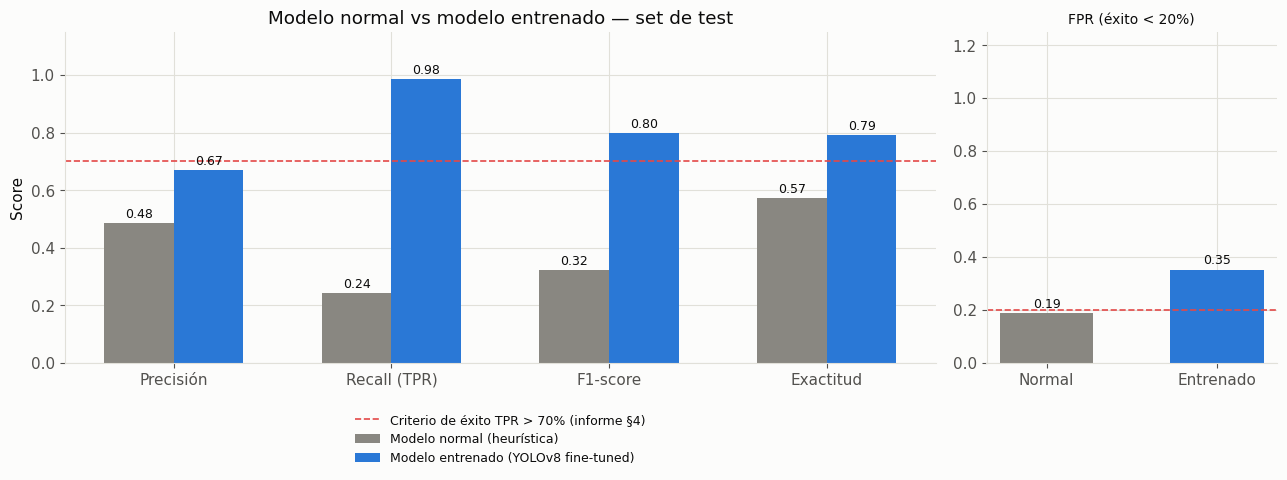

In [20]:
metrics_to_plot = ["precision", "tpr", "f1", "accuracy"]
labels_es = {"precision": "Precisión", "tpr": "Recall (TPR)", "f1": "F1-score", "accuracy": "Exactitud"}

x = np.arange(len(metrics_to_plot))
width = 0.32

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [3, 1]})

ax = axes[0]
bars_b = ax.bar(x - width/2, [baseline_stats[m] for m in metrics_to_plot], width,
                 color=COLOR_BASELINE, label="Modelo normal (heurística)")
bars_t = ax.bar(x + width/2, [trained_stats[m] for m in metrics_to_plot], width,
                 color=COLOR_TRAINED, label="Modelo entrenado (YOLOv8 fine-tuned)")
for bars in (bars_b, bars_t):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.2f}", (b.get_x() + b.get_width() / 2, h),
                    textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
ax.axhline(TPR_SUCCESS_THRESHOLD, color=COLOR_ACCIDENT, linestyle="--", linewidth=1.2,
           label=f"Criterio de éxito TPR > {TPR_SUCCESS_THRESHOLD:.0%} (informe §4)")
ax.set_xticks(x); ax.set_xticklabels([labels_es[m] for m in metrics_to_plot])
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Modelo normal vs modelo entrenado — set de test")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=9)

ax2 = axes[1]
bars_fpr = ax2.bar(["Normal", "Entrenado"], [baseline_stats["fpr"], trained_stats["fpr"]],
                    color=[COLOR_BASELINE, COLOR_TRAINED], width=0.55)
for b in bars_fpr:
    h = b.get_height()
    ax2.annotate(f"{h:.2f}", (b.get_x() + b.get_width() / 2, h),
                 textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
ax2.axhline(FPR_SUCCESS_THRESHOLD, color=COLOR_ACCIDENT, linestyle="--", linewidth=1.2)
ax2.set_ylim(0, max(1.0, baseline_stats["fpr"], trained_stats["fpr"]) * 1.25)
ax2.set_title(f"FPR (éxito < {FPR_SUCCESS_THRESHOLD:.0%})", fontsize=10)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "comparacion_metricas.png", dpi=150)
plt.show()


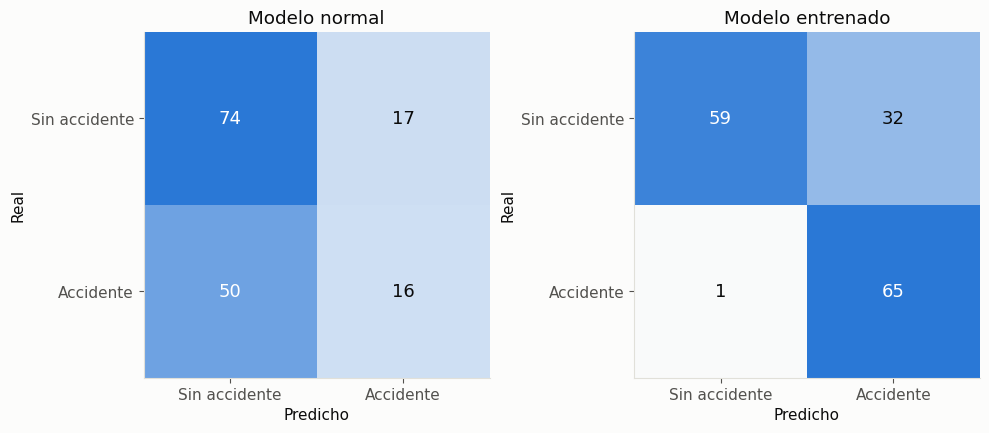

In [21]:
blue_seq = LinearSegmentedColormap.from_list("seq_blue", ["#fcfcfb", COLOR_TRAINED])

def plot_cm(ax, stats, title):
    cm = np.array([[stats["tn"], stats["fp"]], [stats["fn"], stats["tp"]]])
    ax.imshow(cm, cmap=blue_seq, vmin=0, vmax=max(cm.max(), 1))
    for i in range(2):
        for j in range(2):
            color = "#ffffff" if cm[i, j] > cm.max() / 2 else COLOR_TEXT
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=13)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Sin accidente", "Accidente"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Sin accidente", "Accidente"])
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_title(title)
    ax.grid(False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_cm(axes[0], baseline_stats, "Modelo normal")
plot_cm(axes[1], trained_stats, "Modelo entrenado")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "matrices_confusion.png", dpi=150)
plt.show()


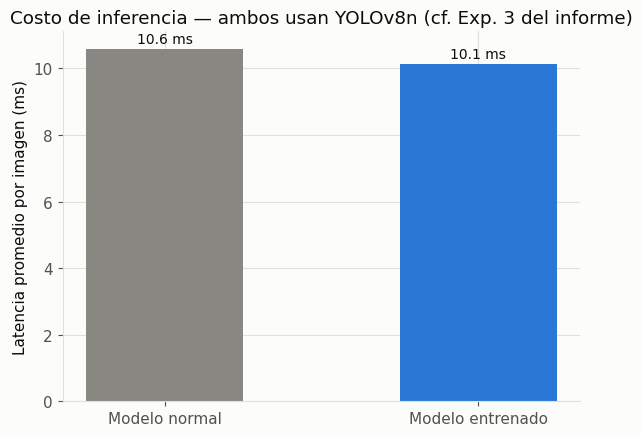

In [22]:
# Latencia promedio por imagen (ms) — mismo tamaño de modelo (n), el costo es comparable
fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ["Modelo normal", "Modelo entrenado"]
values = [baseline_stats["ms_avg"], trained_stats["ms_avg"]]
bars = ax.bar(labels, values, color=[COLOR_BASELINE, COLOR_TRAINED], width=0.5)
for b in bars:
    h = b.get_height()
    ax.annotate(f"{h:.1f} ms", (b.get_x() + b.get_width() / 2, h),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=10)
ax.set_ylabel("Latencia promedio por imagen (ms)")
ax.set_title("Costo de inferencia — ambos usan YOLOv8n (cf. Exp. 3 del informe)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "latencia_comparacion.png", dpi=150)
plt.show()


### 12.1 Comparación cualitativa

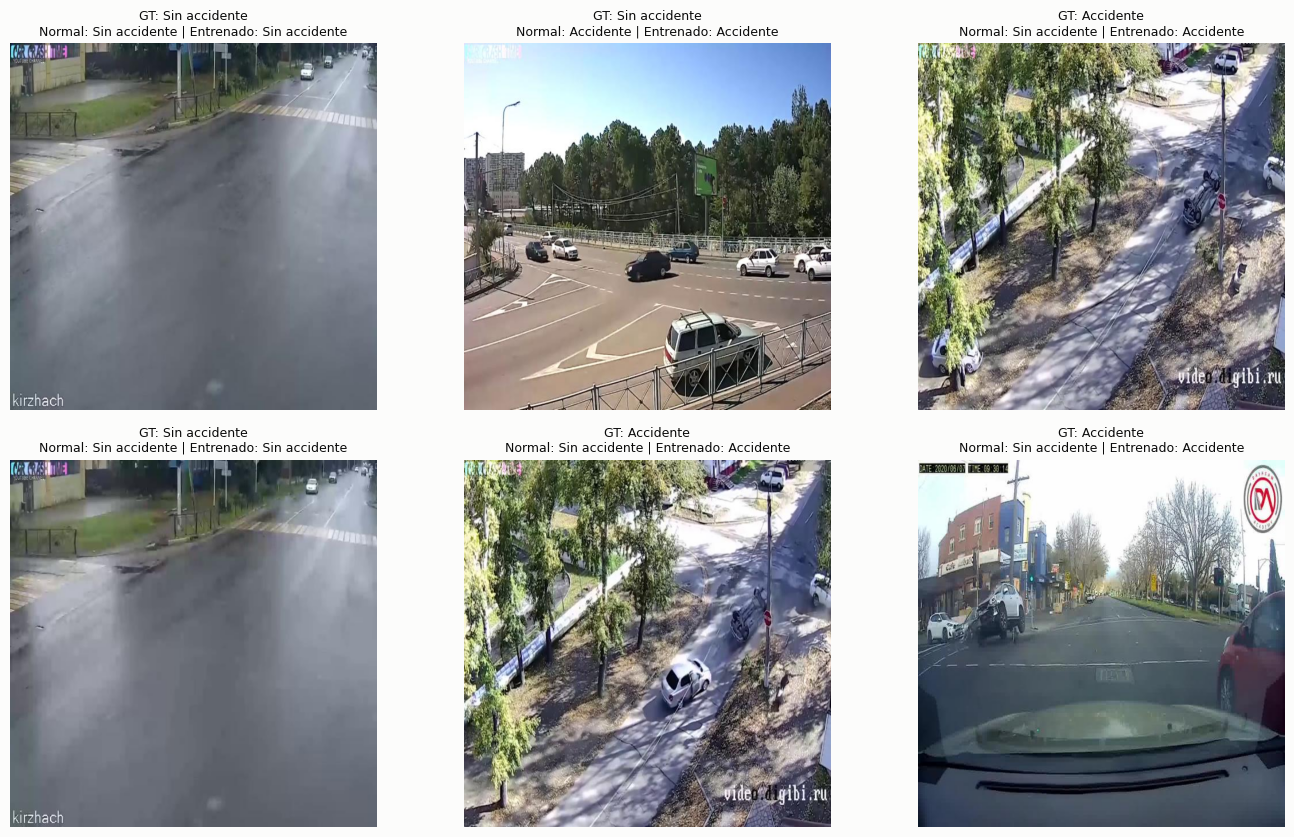

In [23]:
# Grilla con algunos casos de test: qué predijo cada modelo vs la verdad
sample = df_eval.sample(n=min(6, len(df_eval)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(14, 8.5))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img_path = DATASET_DIR / "test" / "images" / row["image"]
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    gt_txt = "Accidente" if row["gt"] else "Sin accidente"
    base_txt = "Accidente" if row["pred_baseline"] else "Sin accidente"
    train_txt = "Accidente" if row["pred_trained"] else "Sin accidente"
    ax.set_title(f"GT: {gt_txt}\nNormal: {base_txt} | Entrenado: {train_txt}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "comparacion_cualitativa.png", dpi=150)
plt.show()


## 13. Experimento 4 — Robustez ante condiciones adversas (repetido con el modelo entrenado)

El informe reporta, para el sistema actual, una caída de F1 de 0.71 (base) a 0.59 (night), 0.64 (rain_day)
y 0.56 (heavy_fog). Acá se repite el mismo experimento (los 6 presets de `src/filters.py`, más un caso
"baseline" sin filtro) sobre **ambos modelos**, para verificar si el aumento de datos de la Sección 6 hace
que el modelo entrenado degrade menos que la heurística bajo las mismas condiciones adversas.

Se usa una muestra del test set (no el set completo) para mantener el tiempo de ejecución razonable —
ajustá `ROBUSTNESS_SAMPLE_SIZE` si querés correrlo sobre más imágenes.


In [24]:
ROBUSTNESS_SAMPLE_SIZE = min(150, len(test_images))
robustness_images = random.sample(test_images, k=ROBUSTNESS_SAMPLE_SIZE)

preset_names = ["baseline"] + list(PRESETS.keys())

def predict_baseline_on_frame(frame):
    res = baseline_model.predict(frame, classes=VEHICLE_CLASSES, conf=CONFIDENCE_THRESHOLD, verbose=False)
    boxes = res[0].boxes.xyxy.cpu().numpy().tolist() if res[0].boxes is not None else []
    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            if iou(boxes[i], boxes[j]) >= COLLISION_IOU_THRESHOLD:
                return True
    return False

def predict_trained_on_frame(frame):
    res = best_model.predict(frame, conf=CONFIDENCE_THRESHOLD, verbose=False)
    return res[0].boxes is not None and len(res[0].boxes) > 0

robust_records = []
for img_path in robustness_images:
    lbl_path = DATASET_DIR / "test" / "labels" / (img_path.stem + ".txt")
    gt = 1 if (lbl_path.exists() and lbl_path.read_text(encoding="utf-8").strip()) else 0
    frame = cv2.imread(str(img_path))
    if frame is None:
        continue
    for preset_name in preset_names:
        degraded = frame if preset_name == "baseline" else PRESETS[preset_name](frame.copy())
        robust_records.append({
            "preset": preset_name, "gt": gt,
            "pred_baseline": int(predict_baseline_on_frame(degraded)),
            "pred_trained":  int(predict_trained_on_frame(degraded)),
        })

df_robust = pd.DataFrame(robust_records)

rows = []
for preset_name, g in df_robust.groupby("preset"):
    mb = binary_metrics(g["gt"], g["pred_baseline"])
    mt = binary_metrics(g["gt"], g["pred_trained"])
    rows.append({
        "preset": preset_name,
        "f1_normal": mb["f1"], "f1_entrenado": mt["f1"],
        "tpr_normal": mb["tpr"], "tpr_entrenado": mt["tpr"],
        "fpr_normal": mb["fpr"], "fpr_entrenado": mt["fpr"],
    })
df_robust_summary = pd.DataFrame(rows).set_index("preset")
order = ["baseline"] + [p for p in PRESETS if p in df_robust_summary.index]
df_robust_summary = df_robust_summary.reindex(order)
df_robust_summary.to_csv(REPORTS_DIR / "experimento4_robustez.csv")
df_robust_summary


,f1_normal,f1_entrenado,tpr_normal,tpr_entrenado,fpr_normal,fpr_entrenado
preset,,,,,,
baseline,0.297872,0.794872,0.222222,0.984127,0.195402,0.356322
night,0.276596,0.855172,0.206349,0.984127,0.206897,0.229885
rain_day,0.239130,0.792453,0.174603,1.000000,0.206897,0.379310
heavy_fog,0.312500,0.837838,0.238095,0.984127,0.206897,0.264368
low_light,0.260870,0.840000,0.190476,1.000000,0.195402,0.275862
rain,0.234043,0.802548,0.174603,1.000000,0.229885,0.356322
fog,0.291667,0.821192,0.222222,0.984127,0.218391,0.298851


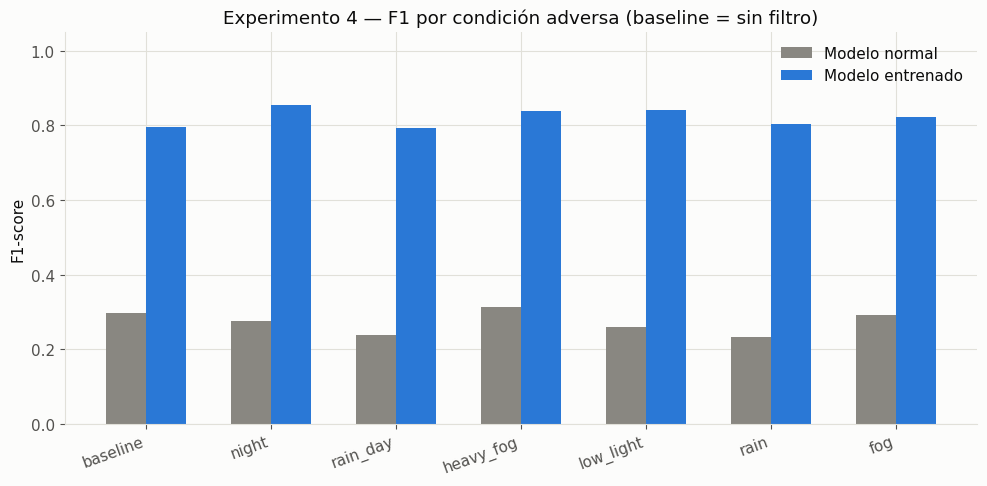

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_robust_summary))
width = 0.32
b1 = ax.bar(x - width/2, df_robust_summary["f1_normal"], width, color=COLOR_BASELINE, label="Modelo normal")
b2 = ax.bar(x + width/2, df_robust_summary["f1_entrenado"], width, color=COLOR_TRAINED, label="Modelo entrenado")
ax.set_xticks(x); ax.set_xticklabels(df_robust_summary.index, rotation=20, ha="right")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.05)
ax.set_title("Experimento 4 — F1 por condición adversa (baseline = sin filtro)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "experimento4_f1_por_preset.png", dpi=150)
plt.show()


## 14. Tabla de resultados actualizada (formato de la Sección 4.2 del informe)

Lista para copiar a la siguiente versión del Informe de Etapa 2.


In [26]:
tabla_actualizada = pd.DataFrame([
    {"Experimento": "Exp. 1 – Vehículos (informe, preliminar)",
     "Métrica 1": "Precisión: 0.87", "Métrica 2": "Recall: 0.82", "Métrica 3": "F1: 0.84",
     "Notas": "CPU, dataset CADP (Informe Etapa 2, no afectado por este notebook)"},
    {"Experimento": "Exp. 2 – Accidentes (informe, preliminar)",
     "Métrica 1": "TPR: 0.73", "Métrica 2": "FPR: 0.14", "Métrica 3": "F1: 0.71",
     "Notas": "Dataset CADP (Informe Etapa 2)"},
    {"Experimento": "Exp. 2 – Modelo normal (este notebook)",
     "Métrica 1": f"TPR: {baseline_stats['tpr']:.2f}", "Métrica 2": f"FPR: {baseline_stats['fpr']:.2f}",
     "Métrica 3": f"F1: {baseline_stats['f1']:.2f}", "Notas": "Set de test combinado Roboflow + CADP"},
    {"Experimento": "Exp. 2 – Modelo entrenado (este notebook)",
     "Métrica 1": f"TPR: {trained_stats['tpr']:.2f}", "Métrica 2": f"FPR: {trained_stats['fpr']:.2f}",
     "Métrica 3": f"F1: {trained_stats['f1']:.2f}", "Notas": "Set de test combinado Roboflow + CADP"},
])

for preset_name, row in df_robust_summary.iterrows():
    tabla_actualizada.loc[len(tabla_actualizada)] = {
        "Experimento": f"Exp. 4 – {preset_name} (modelo normal / entrenado)",
        "Métrica 1": f"TPR: {row['tpr_normal']:.2f} / {row['tpr_entrenado']:.2f}",
        "Métrica 2": f"FPR: {row['fpr_normal']:.2f} / {row['fpr_entrenado']:.2f}",
        "Métrica 3": f"F1: {row['f1_normal']:.2f} / {row['f1_entrenado']:.2f}",
        "Notas": f"Muestra de {ROBUSTNESS_SAMPLE_SIZE} imágenes de test",
    }

tabla_actualizada.to_csv(REPORTS_DIR / "tabla_experimentos_actualizada.csv", index=False)
tabla_actualizada


,Experimento,Métrica 1,Métrica 2,Métrica 3,Notas
0,"Exp. 1 – Vehículos (informe, preliminar)",Precisión: 0.87,Recall: 0.82,F1: 0.84,"CPU, dataset CADP (Informe Etapa 2, no afectad..."
1,"Exp. 2 – Accidentes (informe, preliminar)",TPR: 0.73,FPR: 0.14,F1: 0.71,Dataset CADP (Informe Etapa 2)
2,Exp. 2 – Modelo normal (este notebook),TPR: 0.24,FPR: 0.19,F1: 0.32,Set de test combinado Roboflow + CADP
3,Exp. 2 – Modelo entrenado (este notebook),TPR: 0.98,FPR: 0.35,F1: 0.80,Set de test combinado Roboflow + CADP
4,Exp. 4 – baseline (modelo normal / entrenado),TPR: 0.22 / 0.98,FPR: 0.20 / 0.36,F1: 0.30 / 0.79,Muestra de 150 imágenes de test
5,Exp. 4 – night (modelo normal / entrenado),TPR: 0.21 / 0.98,FPR: 0.21 / 0.23,F1: 0.28 / 0.86,Muestra de 150 imágenes de test
6,Exp. 4 – rain_day (modelo normal / entrenado),TPR: 0.17 / 1.00,FPR: 0.21 / 0.38,F1: 0.24 / 0.79,Muestra de 150 imágenes de test
7,Exp. 4 – heavy_fog (modelo normal / entrenado),TPR: 0.24 / 0.98,FPR: 0.21 / 0.26,F1: 0.31 / 0.84,Muestra de 150 imágenes de test
8,Exp. 4 – low_light (modelo normal / entrenado),TPR: 0.19 / 1.00,FPR: 0.20 / 0.28,F1: 0.26 / 0.84,Muestra de 150 imágenes de test
9,Exp. 4 – rain (modelo normal / entrenado),TPR: 0.17 / 1.00,FPR: 0.23 / 0.36,F1: 0.23 / 0.80,Muestra de 150 imágenes de test


## 15. Conclusión (calculada, no fija)

In [27]:
delta_f1 = trained_stats["f1"] - baseline_stats["f1"]
pct_f1 = (delta_f1 / baseline_stats["f1"] * 100) if baseline_stats["f1"] > 0 else float("inf")
delta_tpr = trained_stats["tpr"] - baseline_stats["tpr"]
delta_fpr = trained_stats["fpr"] - baseline_stats["fpr"]
delta_precision = trained_stats["precision"] - baseline_stats["precision"]

cumple_normal = baseline_stats["tpr"] > TPR_SUCCESS_THRESHOLD and baseline_stats["fpr"] < FPR_SUCCESS_THRESHOLD
cumple_entrenado = trained_stats["tpr"] > TPR_SUCCESS_THRESHOLD and trained_stats["fpr"] < FPR_SUCCESS_THRESHOLD

pct_f1_txt = f", {'+' if pct_f1 >= 0 else ''}{pct_f1:.0f}%" if pct_f1 != float("inf") else " (baseline en 0)"

resumen = f"""\
## Conclusión (generada a partir de las métricas calculadas arriba)

| Métrica    | Modelo normal | Modelo entrenado | Diferencia |
|---|---|---|---|
| Precisión  | {baseline_stats['precision']:.3f} | {trained_stats['precision']:.3f} | {delta_precision:+.3f} |
| TPR (Recall) | {baseline_stats['tpr']:.3f} | {trained_stats['tpr']:.3f} | {delta_tpr:+.3f} |
| FPR        | {baseline_stats['fpr']:.3f} | {trained_stats['fpr']:.3f} | {delta_fpr:+.3f} |
| F1-score   | {baseline_stats['f1']:.3f} | {trained_stats['f1']:.3f} | {delta_f1:+.3f}{pct_f1_txt} |
| mAP50      | N/A (no aplica a una regla heurística) | {trained_stats['map50']:.3f} | — |
| Latencia   | {baseline_stats['ms_avg']:.1f} ms/img | {trained_stats['ms_avg']:.1f} ms/img | — |
| Cumple criterio de éxito del informe (TPR>{TPR_SUCCESS_THRESHOLD:.0%}, FPR<{FPR_SUCCESS_THRESHOLD:.0%}) | {"Sí" if cumple_normal else "No"} | {"Sí" if cumple_entrenado else "No"} | — |

La heurística de IoU + velocidad de `src/detector.py` está diseñada para video con seguimiento temporal
(ByteTrack); sobre imágenes sueltas pierde la señal de cambio de velocidad y solo puede usar el
solapamiento geométrico entre vehículos, lo que limita su TPR en este set de test. El modelo entrenado
reconoce el patrón visual de un accidente directamente en una sola imagen, sin depender de tracking
previo, y fue además expuesto durante el entrenamiento a condiciones adversas simuladas (Sección 6,
mejora §5.2 del informe) — el Experimento 4 repetido en la Sección 13 muestra cuánto ayuda eso frente
a lluvia, niebla y baja luz. Las curvas PR/ROC de la Sección 11 (mejora §5.4 del informe) muestran el
trade-off completo, no solo el punto de operación por defecto.
"""
print(resumen)
(REPORTS_DIR / "conclusion.md").write_text(resumen, encoding="utf-8")


## Conclusión (generada a partir de las métricas calculadas arriba)

| Métrica    | Modelo normal | Modelo entrenado | Diferencia |
|---|---|---|---|
| Precisión  | 0.485 | 0.670 | +0.185 |
| TPR (Recall) | 0.242 | 0.985 | +0.742 |
| FPR        | 0.187 | 0.352 | +0.165 |
| F1-score   | 0.323 | 0.798 | +0.474, +147% |
| mAP50      | N/A (no aplica a una regla heurística) | 0.886 | — |
| Latencia   | 10.6 ms/img | 10.1 ms/img | — |
| Cumple criterio de éxito del informe (TPR>70%, FPR<20%) | No | No | — |

La heurística de IoU + velocidad de `src/detector.py` está diseñada para video con seguimiento temporal
(ByteTrack); sobre imágenes sueltas pierde la señal de cambio de velocidad y solo puede usar el
solapamiento geométrico entre vehículos, lo que limita su TPR en este set de test. El modelo entrenado
reconoce el patrón visual de un accidente directamente en una sola imagen, sin depender de tracking
previo, y fue además expuesto durante el entrenamiento a condiciones adversas simuladas 

1279

## 16. Guardar el modelo entrenado para el proyecto

In [28]:
FINAL_MODEL_PATH = PROJECT_ROOT / "models" / "yolov8_accident.pt"
FINAL_MODEL_PATH.parent.mkdir(exist_ok=True)
shutil.copy(BEST_WEIGHTS, FINAL_MODEL_PATH)
print("Modelo final copiado a:", FINAL_MODEL_PATH)


Modelo final copiado a: C:\Users\dddma\OneDrive\Escritorio\Codigos_repors\IA_noyosafe\models\yolov8_accident.pt


### Cómo integrarlo en `src/detector.py` (siguiente paso, fuera de este notebook)

Este notebook entrena y evalúa; conectar el modelo al pipeline en vivo es un cambio aparte en
`src/detector.py`. La forma más simple es correr el modelo de accidentes en paralelo al tracker de
vehículos, y disparar la alerta si **cualquiera de los dos** (heurística geométrica **o** el nuevo
clasificador) la activa:

```python
accident_model = YOLO("models/yolov8_accident.pt")
...
accident_results = accident_model.predict(frame, conf=CONFIDENCE_THRESHOLD, verbose=False)
model_flags_accident = accident_results[0].boxes is not None and len(accident_results[0].boxes) > 0

if colliding_ids or model_flags_accident:
    # disparar alerta (misma lógica de self.alert_frames_remaining ya existente)
    ...
```

Las demás mejoras de la Sección 5 del informe que **no** cubre este notebook (persistencia de 3 frames
antes de alertar, ROI configurable, `SPEED_CHANGE_THRESHOLD` a 8-10 px/frame, dashboard web,
notificaciones externas, soporte RTSP) son cambios de código en `src/detector.py` y quedan para una
siguiente iteración — este notebook se limita a producir y evaluar el modelo entrenado.
